In [169]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import glob, os
import SFI
import SFI.OLI_bases
import jax.numpy as jnp
from jax import random
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import pickle
from scipy.spatial.distance import jensenshannon
import csv


exp 2 M=4,lam=jnp.array([0.77, 2.8, 7.1]))
exp 18 best but not great S_last_exp18, descriptor = Run_Force_inference(X_last, t_last,K=3, M=5,lam=jnp.array([0.3,3.5,12]))

In [160]:
def get_experimentID_fightbouts(path):

    tracking_folder = os.path.dirname(path)

    loadpaths = glob.glob(os.path.join(tracking_folder, "*results.h5"))
    loadpaths.sort()

    expNames = [os.path.basename(p)[:23] for p in loadpaths]

    target_expName = os.path.basename(path)[:23]
    expIdx = expNames.index(target_expName)

    fightbout_path = os.path.join(tracking_folder, "fightBouts.h5")

    with h5py.File(fightbout_path, "r") as j:
        fb = j["fight_bout_info_noDurThresh"][:]

    fightbouts = fb[fb[:, 0].astype(int) == expIdx]


    return expIdx, fightbouts
EXP_id , fightbout = get_experimentID_fightbouts( "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200213_154940_tracking_results.h5")

print(fightbout)

[[     5 448500 559400 110900]]


In [161]:
def make_winner_df():
    main_load_folder = '../data/tracking_results'
    other_info_loadpath = os.path.join(main_load_folder, 'winners_losers_inconclusive.h5')
    with h5py.File(other_info_loadpath, 'r') as hf:
        winner_idxs = hf['winner_idxs'][:]
        loser_idxs = hf['loser_idxs'][:]
        conclusive_winner_loser = hf['conclusive_winner_loser'][:]
        already_established_dominance = hf['already_established_dominance'][:] 
        winner_idxs = np.array(winner_idxs)

    df = pd.DataFrame({
        "EXP_id": np.arange(len(winner_idxs)),
        "winnerIdx": winner_idxs,
    })
    df = df[~df["EXP_id"].isin([4,9,16,21])].reset_index(drop=True)

    return df
print(make_winner_df())

    EXP_id  winnerIdx
0        0          1
1        1          0
2        2          1
3        3          1
4        5          1
5        6          0
6        7          0
7        8          1
8       10          1
9       11          0
10      12          1
11      13          1
12      14          0
13      15          0
14      17          1
15      18          0
16      19          1
17      20          1


In [162]:
def prepare_data(path,fightnumber = 0,infight =True):
    "Prepare the data make it ready to calculate dpp,theta1 and theta2"
    "if infight = True return data with only the frist infight bouts otherwise it returns total trajectory  "

    path = path
    f = h5py.File(path, "r")

    X = f["tracks_3D_smooth"][:]
    EXP_id , fightbout = get_experimentID_fightbouts(path)
    if infight == True and fightbout.size > 0:
        X_coordinates = X[fightbout[fightnumber,1]:fightbout[fightnumber,2],:,:,:]
    else:
        X_coordinates = X.copy()
    return X_coordinates,fightbout[fightnumber]

path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200217_160052_tracking_results.h5"
X_coordinates_3, fightbout = prepare_data(path,fightnumber = 0,infight =False)
print(fightbout)
def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def calculate_theta(fish0,fish1):
    vector_fish0 = (fish0[:,0,:] - fish0[:,1,:]) # difference in heading of head and pec
    orientation_fish0 = vector_fish0/np.linalg.norm(vector_fish0, axis=1, keepdims=True)

    theta0 = np.arctan2(orientation_fish0[:, 1],  orientation_fish0[:, 0])

    r_01 = fish1[:,1,:] - fish0[:,1,:] 
    phi_01 = np.arctan2(r_01[:,1],r_01[:,0]) #dy,dx

    theta0 = np.arctan2(vector_fish0[:, 1], vector_fish0[:, 0])
    psi_01 = phi_01 - theta0
    psi_01 = wrap_pi(psi_01) # wrap interval from -pi to pi
    return psi_01

[     7  91500 127400  35900]


In [163]:
def js_score(real, sim, bins, range_):
    hist_real, bin_edges = np.histogram(real, bins=bins, range=range_)
    hist_sim, _ = np.histogram(sim, bins=bin_edges, range=range_)

    p = hist_real / np.sum(hist_real)
    q = hist_sim / np.sum(hist_sim)

    return jensenshannon(p, q)


def average_js_score(real_dpp, real_t1, real_t2, traj_sim):
    score_dpp = js_score(real_dpp, np.array(traj_sim[:, 0]), bins=50, range_=(0, 20))
    score_t1  = js_score(real_t1,  np.array(traj_sim[:, 1]), bins=50, range_=(-np.pi, np.pi))
    score_t2  = js_score(real_t2,  np.array(traj_sim[:, 2]), bins=50, range_=(-np.pi, np.pi))
    return (score_dpp + score_t1 + score_t2) / 3


In [323]:
def calculate_variables(coordinates_cleaned):
    "input are the coordinates and returns dpp,theta_i and theta_j"

    fish_i = coordinates_cleaned[:,0,:,:]
    fish_j = coordinates_cleaned[:,1,:,:]

    pec_fish_i = coordinates_cleaned[:,0,1,:]
    pec_fish_j = coordinates_cleaned[:,1,1,:]

    d_pp = np.linalg.norm((pec_fish_j-pec_fish_i), axis=1) 
    
    theta_i = calculate_theta(fish_i,fish_j)
    theta_j = calculate_theta(fish_j,fish_i)

    return d_pp, theta_i,theta_j
    
def clean_data(d_pp,theta_i,theta_j):
    mask = (np.isfinite(d_pp) &np.isfinite(theta_i) & np.isfinite(theta_j))
    return d_pp[mask],theta_i[mask],theta_j[mask]


def Build_segmented_data(dpp,theta1,theta2):
    Valid = (np.isfinite(dpp) &np.isfinite(theta1) & np.isfinite(theta2))
    valid_idx = np.where(Valid)[0]

    X_list = []
    time_list = []
    segid_list = []
    seg_ranges = []
    start = 0
    t_offset = 0
    seg_id = 0

    for k in range(1, len(valid_idx) + 1):
        if k == len(valid_idx) or valid_idx[k] != valid_idx[k - 1] + 1: # if there is the end of trajectory or a hole 

            seg_idx = valid_idx[start:k]

            if len(seg_idx) > 5:
                D_seg = dpp[seg_idx]
                th1_seg = np.unwrap(theta1[seg_idx])
                th2_seg = np.unwrap(theta2[seg_idx])

                X_list.append(np.column_stack([D_seg, th1_seg, th2_seg]))
                time_list.append(np.arange(len(seg_idx)) + t_offset)
                segid_list.append(np.full(len(seg_idx), seg_id, dtype=int))
                seg_ranges.append((seg_idx[0], seg_idx[-1]))

                t_offset += len(seg_idx) + 1
                seg_id += 1

            start = k

    X = np.vstack(X_list)
    time_idx = np.concatenate(time_list)
    segment_ids = np.concatenate(segid_list)
    return X, time_idx, segment_ids, seg_ranges

def subsample_random_segments(X, segment_ids, fraction=0.85):
    np.random.seed(5)
    unique_segments = np.unique(segment_ids)
    n_keep = int(fraction * len(unique_segments))
    keep_seg = np.random.choice(unique_segments,size=n_keep,replace= False)

    X_list = []
    time_list = []
    t_offset = 0
    for seg in keep_seg:
        indices = np.where(segment_ids == seg)[0]
        X_seg = X[indices]
        X_list.append(X_seg)
        time_list.append(np.arange(len(X_seg)) + t_offset)
        t_offset += len(X_seg) + 1

    X_new = np.vstack(X_list)
    time_idx_new = np.concatenate(time_list)
    return X_new, time_idx_new

def Run_Force_inference(X,time_idx,K,M,lam):
    traj = SFI.StochasticTrajectoryData(X, time_idx, 0.01)
    poly_1d,poly_describe = SFI.OLI_bases.polynomial_basis(dim=1,order=K)
    fourier1d_F1 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center= jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    fourier1d_F2 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center = jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    
    def radial_basis(D):

        #lam = jnp.array([0.8,2.5, 6.0]) good for second experiment
        #lam = jnp.array([0.7,2.7, 7.0]) #good for second experiment
        #lam = jnp.array([0.5, 1.0,5.0]) good for frist 
        #p_exp = jnp.exp(-D /lam)
        return jnp.exp(-D / lam)#p_exp #jnp.concatenate([p_poly,p_exp])

    def C_func(x):
        D  = x[0]
        th1 = x[1]
        th2 = x[2]

        p = radial_basis(D)      
        f1 = fourier1d_F1(jnp.array([th1]))
        f2 = fourier1d_F2(jnp.array([th2]))  
        triple = jnp.einsum('i,j,k->ijk', p, f1[1:], f2[1:]).reshape(-1)
        
        phi = jnp.concatenate([
        p, f1, f2, jnp.outer(p, f1[1:]).reshape(-1),jnp.outer(f2[1:], f1[1:]).reshape(-1),
        jnp.outer(p, f2[1:]).reshape(-1),triple], axis=0) # ,triple, 
        return phi 
    
    S = SFI.OverdampedLangevinInference(traj)
    S.compute_diffusion_constant(method="MSD")
    (funcs_and_grad, descriptor) = SFI.OLI_bases.basis_selector(
        {"type": "custom_scalar", "functions": C_func},
        dimension=3,
        output="vector"
    )
  
    basis_F, grad_F = funcs_and_grad
    S.infer_force_linear(basis_linear=basis_F, basis_linear_gradient=grad_F)
    #S.sparsify_force()
    S.compute_force_error() 
    S.print_report()
    return S, descriptor


(83900,)


/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_35511/947734979.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_35511/947734979.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend()


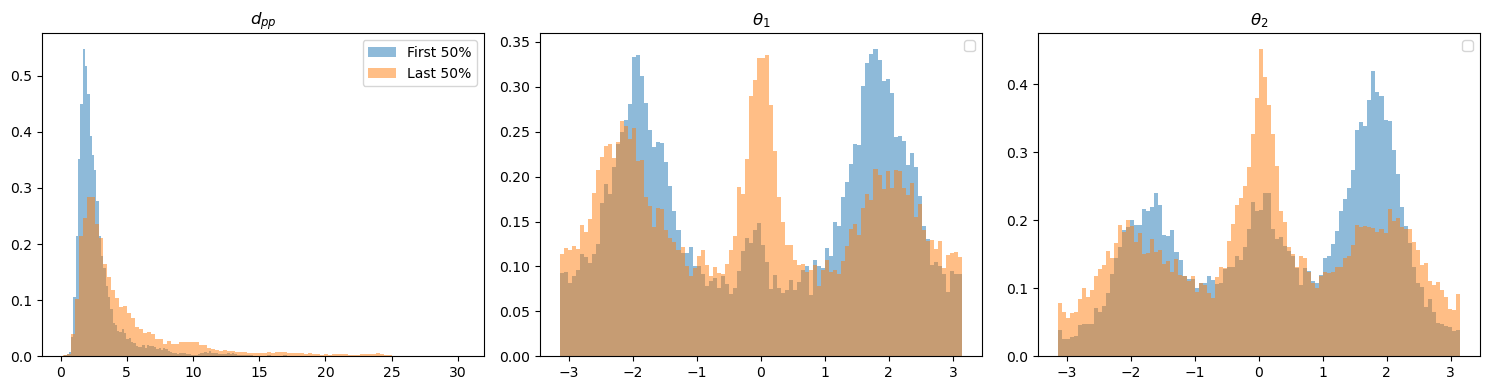

[ 0.9941809  2.6250224 11.159346 ]


In [337]:
#path ="/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200525_161602_tracking_results.h5" # exp 15
#path ="/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_153857_tracking_results.h5"

#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_181614_tracking_results.h5" #exp3
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200213_154940_tracking_results.h5" #exp5#
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200214_153519_tracking_results.h5" #exp6
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200217_160052_tracking_results.h5" #exp7
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200127_143538_tracking_results.h5" #exp0
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200129_140656_tracking_results.h5" #exp1
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200218_153008_tracking_results.h5" #exp 8
#path  = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200327_154737_tracking_results.h5" #exp10
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200330_161100_tracking_results.h5" #exp 11
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200331_162136_tracking_results.h5" #exp12
path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200520_152810_tracking_results.h5"
X_coordinates, fightbout = prepare_data(path,0,True)
dpp,theta1,theta2 = calculate_variables(X_coordinates[:,:,:,:])
print(dpp.shape)

ig, axs = plt.subplots(1, 3, figsize=(15,4))
d_pp_c, theta_i_c, theta_j_c = clean_data(dpp, theta1, theta2)
N = len(d_pp_c)

dpp_85= d_pp_c[:int(0.5*N)]
dpp_15 = d_pp_c[int(0.5*N):]

thetai_85 = theta_i_c[:int(0.5*N)]
thetai_15 = theta_i_c[int(0.5*N):]

thetaj_85 = theta_j_c[:int(0.5*N)]
thetaj_15 = theta_j_c[int(0.5*N):]

axs[0].hist(dpp_85, bins=100, alpha=0.5, density = True,label='First 50%')
axs[0].hist(dpp_15, bins=100, alpha=0.5,density = True, label='Last 50%')

#axs[0].hist(dpp_15, bins=80, alpha=0.5,density = True, label='last 15%')

axs[0].set_title(r'$d_{pp}$')
axs[0].legend()

# Theta 1
axs[1].hist(thetai_85, bins=100, alpha=0.5,density = True)
axs[1].hist(thetai_15, bins=100, alpha=0.5, density = True)

#axs[1].hist(thetai_15, bins=80, alpha=0.5, density = True,label='last 15%')

axs[1].set_title(r"$\theta_1$")
axs[1].legend()
# Theta 2
axs[2].hist(thetaj_85, bins=100, alpha=0.5, density = True)
axs[2].hist(thetaj_15, bins=100, alpha=0.5,density = True)

#axs[2].hist(thetaj_15, bins=80, alpha=0.5,density = True, label='last 15%')

axs[2].set_title(r"$\theta_2$")
axs[2].legend()

plt.tight_layout()
save_path = "Exploratory_Figures"
os.makedirs(save_path, exist_ok=True)
#plt.savefig(f"{save_path}/Real_distributions/exp12_fight1.png", dpi=300)
plt.show()

q1, q60, q98 = np.percentile(d_pp_c, [1, 50, 95])
lam_common = jnp.array([q1, q60, q98])
print(lam_common)

In [334]:
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200525_161602_tracking_results.h5"
#d_pp,theta_i,theta_j = calculate_variables(prepare_data(path,True))
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_181614_tracking_results.h5"


#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200525_161602_tracking_results.h5" # exp 15

#path ="/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_153857_tracking_results.h5"

#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_181614_tracking_results.h5"

X_coordinates, fightbout = prepare_data(path,0,infight=True)
dpp,theta1,theta2 = calculate_variables(X_coordinates[:,:,:,:])
print(dpp.shape)
X, time_idx, segment_ids, seg_ranges = Build_segmented_data(dpp, theta1, theta2)

#X, t = subsample_random_segments(X, segment_ids, fraction=1)
#S85, descriptor = Run_Force_inference(X, t, K=3, M=4,lam = jnp.array([0.77, 2.8, 7.1]))
n = int(0.5* len(X))

#X_50 = X[:n]
#t_50 = time_idx[:n]
#print(len(X_50), len(t_50))
X_full,t_full = X, time_idx
X_first,t_first = X[:n],time_idx[:n]
X_last,t_last = X[n:],time_idx[n:]

#S_full, descriptor = Run_Force_inference(X_full, t_full,K=2, M=4,lam=jnp.array([0.77, 2.8, 7.1]))
S_first_exp18, descriptor = Run_Force_inference(X_first, t_first,K=3, M=4,lam=lam_common)
S_last_exp18, descriptor = Run_Force_inference(X_last, t_last,K=3, M=4,lam=lam_common)
#N = len(d_pp)
#dpp_half,thetai_half,thetaj_half = d_pp[:int(N)],theta_i[:int( N)], theta_j[:int( N)]
#X, time_idx,_,_ = Build_segmented_data(d_pp, theta_i, theta_j)
#S_half, descriptor = Run_Force_inference(X,time_idx, K=2, M=3)

(83900,)
Measurement noise trace: -0.02094324305653572.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -0.02094324305653572). 

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[0.22967862 0.00321826 0.00261113]
 [0.00321826 0.6962303  0.15333638]
 [0.00261113 0.15333638 0.6358689 ]]
Measurement noise tensor:
 [[-3.9277491e-03 -6.1541847e-05 -2.7717735e-05]
 [-6.1541854e-05 -8.6117014e-03 -2.1776236e-03]
 [-2.7717726e-05 -2.1776236e-03 -8.4037939e-03]]
Force estimated information: 14034.498046875
Force: estimated normalized mean squared error (sampling only): 0.07139551639556885
Force model:
 +19.03 (±0.6247) b₀ -18.4 (±0.1162) b₁ +16.66 (±0.04163) b₂ -12.55 (±0.04873) b₃ -11.2 (±0.1181) b₄ -10.12 (±0.1087) b₅ -5.76 (±0.1035) b₆ +14.66 (±0.1103) b₇ +2.906 (±0.1008) b₈ +7.418 (±0.1152) b₉ -3.707 (±0.1177) b₁₀ -1.982 (±0.1057) b₁₁ +4.765 (±0.04873) b₁₂ -28.67 (±0.1251) b₁₃ +4.205 (±0.104) b₁₄ +5.585 (±0.1109) b₁₅ +7.018

### Choose the file and if you want total or only in fight

In [335]:
def Simulation(S_model,x0,dt,N_steps,key):
    Diffusion = np.array(S_model.diffusion_average)
    L = jnp.linalg.cholesky(Diffusion)
    x = jnp.array(x0)
    xs = []
    for _ in range(N_steps):
        xs.append(x)
        drift = S_model.force_ansatz(x[None, :])[0] 
        key, subkey = random.split(key)
        xi = random.normal(subkey, (3,))

        x = x + drift * dt + jnp.sqrt(2*dt) *  (L @ xi)
        
        x = x.at[0].set(jnp.clip(x[0], 0.0, 35))  
        x = x.at[1].set(wrap_pi(x[1]))
        x = x.at[2].set(wrap_pi(x[2]))

    return jnp.stack(xs), key
d_pp_c, theta_i_c, theta_j_c = clean_data(dpp, theta1, theta2)

i_first = np.random.randint(0, len(X_first))
i_last  = np.random.randint(0, len(X_last))

x0_first = X_first[i_first]
x0_last  = X_last[i_last]

key = random.PRNGKey(0)
#traj_sim_full, key = Simulation(S_full, x0, dt=0.01, N_steps=500000, key=key)
traj_sim_first, key = Simulation(S_first_exp18, x0_first, dt=0.01, N_steps=500000, key=key)
traj_sim_last, key = Simulation(S_last_exp18, x0_last, dt=0.01, N_steps=500000, key=key)

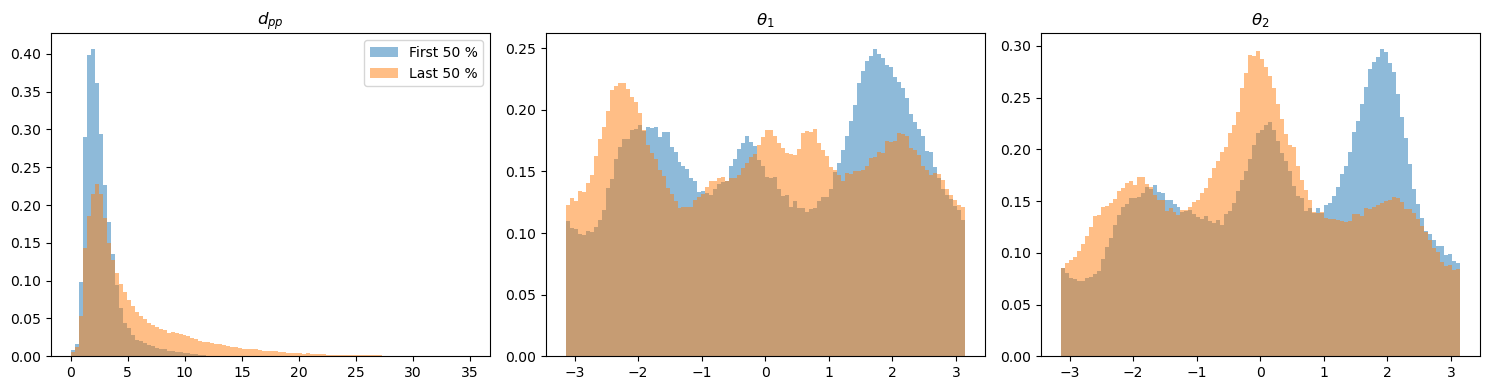

0.10458418373646422
0.08919280280149923


In [336]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].hist(traj_sim_first[:,0],alpha = 0.5,density = True,label=r'First 50 %', bins=100)
axs[0].hist(traj_sim_last[:,0],alpha=0.5,density = True,label=r'Last 50 %', bins=100)
axs[0].legend()
axs[0].set_title(r'$d_{pp}$')

axs[1].hist(wrap_pi(traj_sim_first[:,1]) ,density = True,label = 'uyes',alpha = 0.5,bins=100)
axs[1].hist(wrap_pi(traj_sim_last[:,1]) ,density = True,alpha=0.5,bins=100)
axs[1].set_title(r"$\theta_1$")

axs[2].hist(wrap_pi(traj_sim_first[:,2]),density =True, alpha = 0.5,bins=100)
axs[2].hist(wrap_pi(traj_sim_last[:,2]),density =True, alpha = 0.5,bins=100)

axs[2].set_title(r"$\theta_2$")

plt.tight_layout()
save_path = "Exploratory_Figures"
os.makedirs(save_path, exist_ok=True)
plt.savefig(f"{save_path}/Deterministic_nothingfixed/Distributions_M=3_K=4_exp11_fight1.png", dpi=300)

plt.show()
print(average_js_score(X_first[:,0],wrap_pi(X_first[:,1]),wrap_pi(X_first[:,2]),traj_sim_first))
print(average_js_score(X_last[:,0],wrap_pi(X_last[:,1]),wrap_pi(X_last[:,2]),traj_sim_last))

In [268]:
0.12421767531659685
0.106954464217369 6.

0.10100236858660494
0.121490886198995 - 4.

0.1149282219048967
0.10919732508350956 -5

0.10239015082153922
0.122199457608018 -> last one waS 4 INSTEAD OF 5

0.10340767365905812
0.121758404330935 -> normal

0.15468651589316462
0.11568931547686 -> 1:5

0.10308896950921699
0.11812418199910087 -> all

exp 10 0.10585607011802334
0.1036931839157979

exp 11

0.1280589801080316
0.1039980930856849 shorter cutoff but tail is longer 

0.1284237412497218
0.1080342635905034 -> both 8 longer cutoff


SyntaxError: invalid syntax (1871356626.py, line 2)

Variation ξ_dpp = 0.480
Variation ξ_θ1 = 1.034
Variation ξ_θ2 = 1.013
Mean ξ_dpp = 0.001
Mean ξ_θ1 = 0.002
Mean ξ_θ2 = 0.001


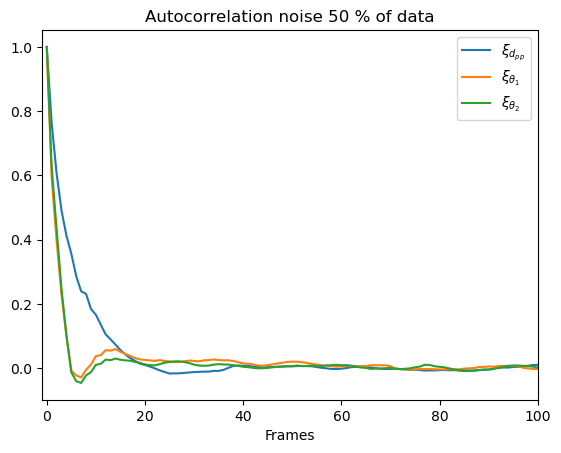

In [40]:
def autocorr(x):
    x = x[np.isfinite(x)] #remove the nans 
    x -= x.mean() #subtract mean
    result = np.correlate(x,x, mode='full') #result = np.correlate(x, x, mode='full')
    result = result[result.size // 2:] # keep only positive values

    return result/result[0]

def Analyse_noise(X,S,dt):
    Diffusion = np.array(S.diffusion_average)
    L = jnp.linalg.cholesky(Diffusion)
    eta_time = np.zeros((len(X[:,1]),3))

    for i in range(len(X[:,1])-1):

        dX = X[i+1,:] - X[i,:]
        F = np.array(S.force_ansatz(X[i:i+1, :])[0])
        R = dX - F*dt
        R[1] = wrap_pi(R[1])
        R[2] = wrap_pi(R[2])

        eta = 1/np.sqrt(2*dt)* np.linalg.inv(L) @ R
        eta_time[i,:] = eta
    dpp_autocorr = autocorr(eta_time[:,0])
    th1_autocorr = autocorr(eta_time[:,1])
    th2_autocorr = autocorr(eta_time[:,2])

    return eta_time,dpp_autocorr,th1_autocorr,th2_autocorr

eta_time,dpp_autocorr,th1_autocorr,th2_autocorr = Analyse_noise(X_first ,S_first_exp18 ,dt=0.01)
eta_time_last,dpp_autocorr_last,th1_autocorr_last,th2_autocorr_last = Analyse_noise(X_last,S_last_exp18,dt=0.01)

print(f'Variation ξ_dpp = {np.var(eta_time[:,0]):.3f}')
print(f'Variation ξ_θ1 = {np.var(eta_time[:,1]):.3f}')
print(f'Variation ξ_θ2 = {np.var(eta_time[:,2]):.3f}')

print(f'Mean ξ_dpp = {np.mean(eta_time[:,0]):.3f}')
print(f'Mean ξ_θ1 = {np.mean(eta_time[:,1]):.3f}')
print(f'Mean ξ_θ2 = {np.mean(eta_time[:,2]):.3f}')

plt.plot(dpp_autocorr,label=r'$\xi_{d_{pp}}$')
plt.plot(th1_autocorr,label =r'$\xi_{\theta_1}$')
plt.plot(th2_autocorr,label =r'$\xi_{\theta_2}$')
plt.title(r'Autocorrelation noise first 50 % of data')
plt.legend()
plt.xlabel('Frames')
plt.xlim(-1,100)
#plt.savefig('Exploratory_Figures/Deterministic_simulation/Autocorrelation_50%.png')

print(f'Variation ξ_dpp = {np.var(eta_time_last[:,0]):.3f}')
print(f'Variation ξ_θ1 = {np.var(eta_time_last[:,1]):.3f}')
print(f'Variation ξ_θ2 = {np.var(eta_time_last[:,2]):.3f}')

print(f'Mean ξ_dpp = {np.mean(eta_time_last[:,0]):.3f}')
print(f'Mean ξ_θ1 = {np.mean(eta_time_last[:,1]):.3f}')
print(f'Mean ξ_θ2 = {np.mean(eta_time_last[:,2]):.3f}')

plt.plot(dpp_autocorr_last,label=r'$\xi_{d_{pp}}$')
plt.plot(th1_autocorr_last,label =r'$\xi_{\theta_1}$')
plt.plot(th2_autocorr_last,label =r'$\xi_{\theta_2}$')
plt.title(r'Autocorrelation noise last 50 % of data')
plt.legend()
plt.xlabel('Frames')
plt.xlim(-1,100)

(517000, 2, 3, 3)
(517000,)
(87000,)


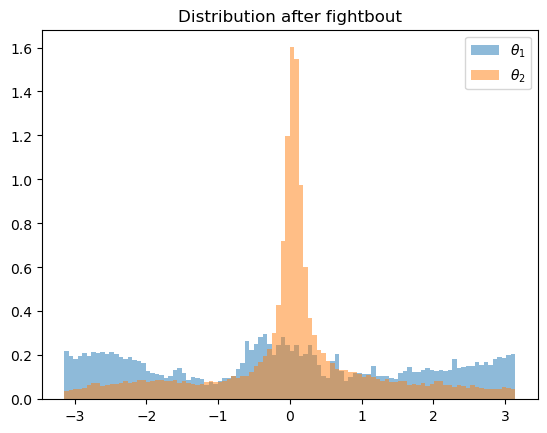

In [61]:
X_coordinates_3, fightbout = prepare_data(path,0,False)
print(X_coordinates_3.shape)
dpp_3,theta1_3,theta2_3 = calculate_variables(X_coordinates_3[:,:,:,:])
print(dpp_3.shape)
dpp_during,theta1_during,theta2_during = dpp_3[430000:],theta1_3[430000:],theta2_3[430000:]
dpp_between,theta1_between,theta2_between = dpp_3[430000:],theta1_3[430000:],theta2_3[430000:]
print(dpp_between.shape)
plt.hist(theta1_between,alpha  =0.5,label = r'$\theta_1$',bins = 100,density = True)
plt.hist(theta2_between,alpha =0.5,label = r'$\theta_2$',bins = 100,density = True)
plt.title('Distribution after fightbout')
plt.legend()

fig, axs = plt.subplots(1, 2, figsize=(15,4))

axs[0].hist(traj_sim_first[:,0],alpha = 0.5,density = True,label=r'First 50 %', bins=100)
axs[0].hist(traj_sim_last[:,0],alpha=0.5,density = True,label=r'Last 50 %', bins=100)
axs[0].legend()


axs[1].hist(wrap_pi(traj_sim_first[:,1]) ,density = True,alpha = 0.5,bins=100)
axs[1].hist(wrap_pi(traj_sim_last[:,1]) ,density = True,alpha=0.5,bins=100)

In [223]:
lambda_list = [
    jnp.array([0.2, 3.0, 10.0]),
    jnp.array([0.3, 3.0, 10.0]),
    jnp.array([0.3, 3.5, 10.0]) 
]

d_pp_c, theta_i_c, theta_j_c = clean_data(dpp, theta1, theta2)

t0 = np.random.randint(0, len(d_pp_c))
x0 = [d_pp_c[t0], theta_i_c[t0], theta_j_c[t0]]

results = []

for i, lam in enumerate(lambda_list):
    print(f"\nTesting lambda set {i+1}: {lam}")

    S_model, descriptor = Run_Force_inference(X_first,t_first, K=2, M=5, lam=lam)

    key = random.PRNGKey(i)
    traj_sim, key = Simulation(S_first_exp18, x0, dt=0.01, N_steps=500000, key=key)

    score = average_js_score(d_pp_c, theta_i_c, theta_j_c, traj_sim)

    results.append((np.array(lam), score))
    print("average JS score =", score)
    
results_sorted = sorted(results, key=lambda x: x[1])

print("\nBest lambda sets:")
for lam, score in results_sorted:
    print("lam =", lam, " score =", score)


Testing lambda set 1: [ 0.2  3.  10. ]
Measurement noise trace: -0.030493274331092834.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -0.030493274331092834). 

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[ 0.5382486  -0.00957509  0.00837141]
 [-0.00957509  1.0297232   0.40675744]
 [ 0.00837141  0.40675744  1.2158723 ]]
Measurement noise tensor:
 [[-8.4536644e-03  2.0285578e-04  9.2137649e-05]
 [ 2.0285578e-04 -9.3234265e-03 -4.3549198e-03]
 [ 9.2137649e-05 -4.3549198e-03 -1.2716183e-02]]
Force estimated information: 24512.80859375
Force: estimated normalized mean squared error (sampling only): 0.07702111452817917
Force model:
 +126.8 (±6.23) b₀ +0.3837 (±0.2466) b₁ -0.7355 (±0.05834) b₂ +0.8581 (±0.06659) b₃ -5.342 (±0.1592) b₄ -0.6658 (±0.1648) b₅ +0.822 (±0.1636) b₆ +0.304 (±0.1672) b₇ +0.06191 (±0.1646) b₈ -0.8252 (±0.1863) b₉ -0.462 (±0.1774) b₁₀ +0.07884 (±0.1726) b₁₁ -1.548 (±0.1734) b₁₂ +0.1833 (±0.1695) 

In [227]:
print("\nBest lambda sets:")
for lam, score in results_sorted:
    print("lam =", lam, " score =", score)


Best lambda sets:
lam = [ 0.3  3.5 10. ]  score = 0.08416288912402903
lam = [ 0.3  3.  10. ]  score = 0.08580598531868505
lam = [ 0.2  3.  10. ]  score = 0.0893774508833638


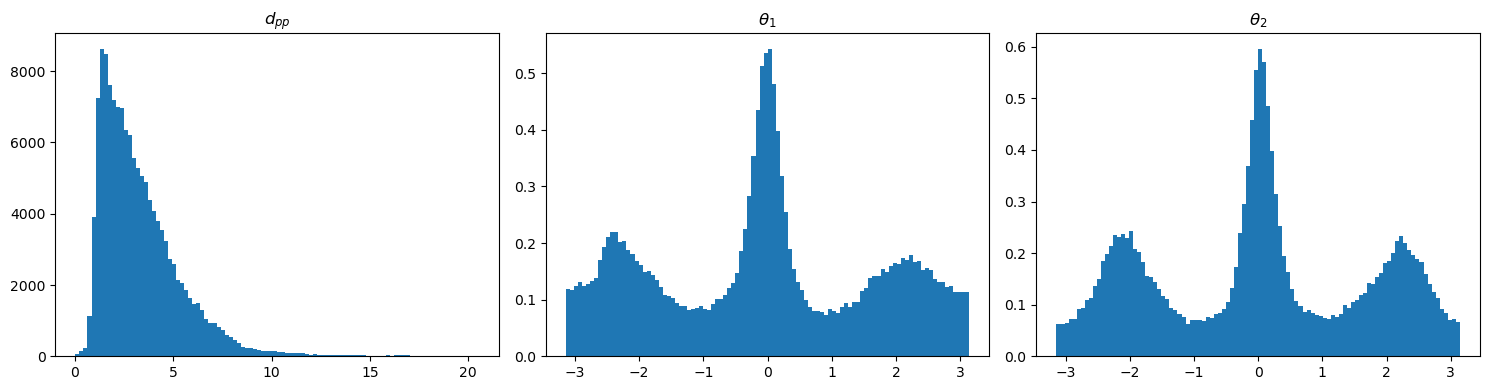

In [256]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))
dpp_50,theta1_50,theta2_50 = dpp[:],theta1[:],theta2[:] 
axs[0].hist(dpp_50[~np.isnan(dpp_50)], bins=100)
#axs[0].axvline(x=1.1, linestyle='--')
axs[0].set_title(r'$d_{pp}$')

axs[1].hist(theta1_50[~np.isnan(theta1_50)], density=True ,bins=100)
axs[1].set_title(r"$\theta_1$")

axs[2].hist(theta2_50[~np.isnan(theta2_50)],density=True ,bins=100)
axs[2].set_title(r"$\theta_2$")

plt.tight_layout()
save_path = "Exploratory_Figures"
os.makedirs(save_path, exist_ok=True)

#plt.savefig(f"{save_path}/Distributions_random_segmentedtrajectories_50%.png", dpi=300)
plt.show()

/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_57497/3175679864.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_57497/3175679864.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend()


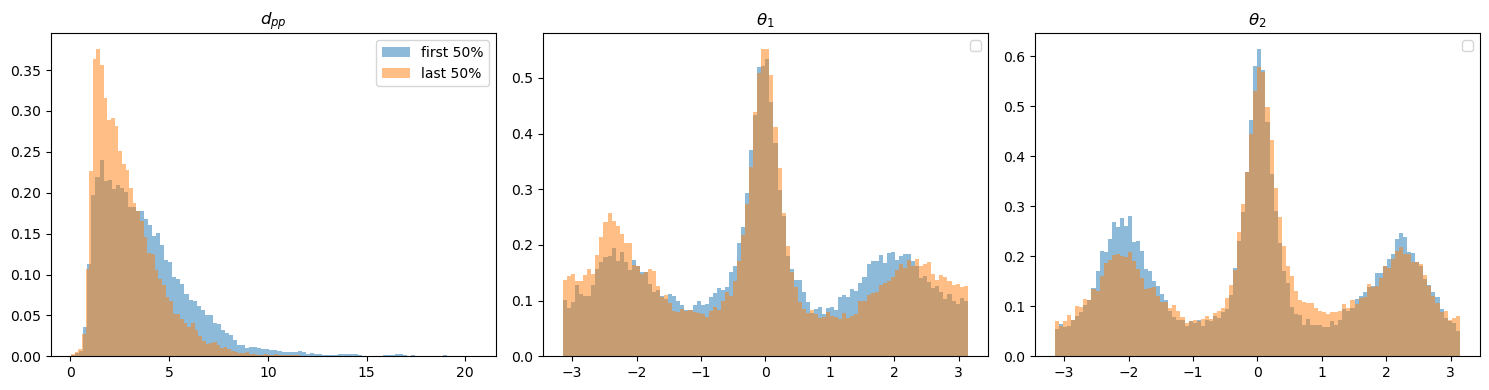

In [319]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))
#d_pp_c, theta_i_c, theta_j_c = clean_data(d_pp, theta_i, theta_j)
N = len(d_pp_c)

dpp_first_real = dpp[:n]
dpp_last_real = dpp[n:]

theta1_first_real = theta1[:n]
theta1_last_real = theta1[n:]

theta2_first_real = theta2[:n]
theta2_last_real = theta2[n:]

axs[0].hist(dpp_first_real, bins=100, alpha=0.5, density = True,label='first 50%')
axs[0].hist(dpp_last_real, bins=100, alpha=0.5,density = True, label='last 50%')


axs[0].set_title(r'$d_{pp}$')
axs[0].legend()

# Theta 1
axs[1].hist(theta1_first_real, bins=100, alpha=0.5,density = True)
axs[1].hist(theta1_last_real, bins=100, alpha=0.5, density = True)


axs[1].set_title(r"$\theta_1$")
axs[1].legend()

# Theta 2
axs[2].hist(theta2_first_real, bins=100, alpha=0.5, density = True)
axs[2].hist(theta2_last_real, bins=100, alpha=0.5,density = True)

axs[2].set_title(r"$\theta_2$")
axs[2].legend()

plt.tight_layout()
plt.show()

In [315]:
#js_full = average_js_score(d_pp_c, theta_i_c, theta_j_c, traj_sim)
js_full = average_js_score(dpp,theta1,theta2,traj_sim_full)
js_first = average_js_score(dpp_first_real,theta1_first_real,theta2_first_real,traj_sim_first)
js_last = average_js_score(dpp_last_real,theta1_last_real,theta2_last_real,traj_sim_last)
print(js_full,js_first,js_last)

0.09547375511146226 0.11282405353728187 0.09787572035777614


In [13]:
def Simulation_anglesfixed(S, D0, theta1, theta2, dt=0.01, N_steps=5000,
                      early_stop=True, force_tol=1e-4, n_consecutive=20):
    D =  D0
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append([D,theta1,theta2])

        FD = float(S.force_ansatz(np.array([[D, theta1, theta2]]))[0][0])
        D = D + FD * dt

        if early_stop:

            if abs(FD) < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append([D, theta1, theta2])
                break

    return jnp.array(xs)

def Simulation_Dfixed(S,x0,dt,N_steps,D,early_stop= True,force_tol = 1e-4,n_consecutive = 20):
    x = jnp.array(x0)
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append(x)

        drift = S.force_ansatz(x[None, :])[0]
        x = x + drift * dt

        x = x.at[0].set(D if D is not None else x[0])
        x = x.at[1].set(wrap_pi(x[1]))
        x = x.at[2].set(wrap_pi(x[2]))

        if early_stop:
            drift_new = S.force_ansatz(x[None, :])[0]
            force_norm = np.linalg.norm(np.array([drift_new[1], drift_new[2]]))
            if force_norm < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append(x) 
                break

    return jnp.stack(xs)

def Simulation_deterministic(S,x0,dt,N_steps,force_tol,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True):
    x = jnp.array(x0)
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append(x)

        drift = S.force_ansatz(x[None, :])[0]
        x = x + drift * dt

        x = x.at[0].set(D if D is not None else jnp.clip(x[0], 0.0, 20.0))
        x = x.at[1].set(theta1 if theta1 is not None else wrap_pi(x[1]))
        x = x.at[2].set(theta2 if theta2 is not None else wrap_pi(x[2]))

        if early_stop:
            force_norm = np.linalg.norm(np.array(S.force_ansatz(x[None, :])[0]))

            if force_norm < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append(x) 
                break
    return jnp.stack(xs)

#t0 = np.random.randint(0, len(d_pp_clean))
#x0 = [d_pp_clean[t0], theta_i_clean[t0], theta_j_clean[t0]]
#traj_sim = Simulation_deterministic(S, x0, dt=0.01, N_steps=50000,D=2.5,theta1 =None, theta2 = None,early_stop= True,force_tol = 1e-4,n_consecutive = 20)

In [136]:
def endpoint_clustering(all_endpoints):
    D_values = np.unique(all_endpoints[:,0])
    clustered_all = []

    for D in D_values:
        pts = all_endpoints[all_endpoints[:,0] == D]
        
        rounded = np.round(pts[:,1:], 3)
        unique_angles = np.unique(rounded, axis=0)
        
        clustered = np.column_stack([np.full(len(unique_angles), D), unique_angles])
        clustered_all.append(clustered)

    clustered_all = np.vstack(clustered_all)
    return clustered_all
import csv
def cluster_endpoints_3d(all_endpoints, decimals=3):
    rounded = np.round(all_endpoints, decimals=decimals)
    clustered = np.unique(rounded, axis=0)
    return clustered

def Find_endpoints(S_model):
    accept_rate = []
    all_endpoints =[]
    startpoints = []
    all_forces = []
    #accepted_trajs = []
    D_values = np.linspace(1, 8, 15)
    length = np.linspace(-np.pi, np.pi, 10,endpoint = False)
    outpath = os.path.abspath("endpoints_forces_real_last50%.csv")
    print("Saving to:", outpath)
    accepted = 0
    with open("endpoints_forces_real_last50%.csv", "w", newline="") as f:
        writer = csv.writer(f)

        # write header
        writer.writerow([
            "d0", "theta10", "theta20",
            "d_final", "theta1_final", "theta2_final",
            "F_d", "F_theta1", "F_theta2"
        ])
        for d_sim in D_values:
            
            for theta_i0 in length:
                for theta_j0 in length:
                    x0 = [d_sim, theta_i0, theta_j0]
                    #x0 = [np.random.uniform(1.0,8.0),np.random.uniform(-np.pi,np.pi),np.random.uniform(-np.pi,np.pi)]
                    traj_sim = Simulation_deterministic(S_model, x0, dt=0.01, N_steps=100000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
                    final_point= traj_sim[-1]
                    force = np.array(S_model.force_ansatz(final_point[None, :])[0])
                    print("x0 =", x0, " final =", np.round(np.array(final_point), 3), " force =", force)
                    #if np.linalg.norm(S_model.force_ansatz(final_point[None, :])[0]) < 1e-3:
                    all_endpoints.append(final_point)
                    all_forces.append(force)
                    startpoints.append(x0)
                    writer.writerow([
                            x0[0], x0[1], x0[2],
                            final_point[0], final_point[1], final_point[2],
                            force[0], force[1], force[2]
                        ])
                    f.flush()
                    accepted+=1
    accept_rate.append(accepted / (len(length) * len(length)*len(D_values)))
    if len(all_endpoints) == 0:
        return np.empty((0, 3)), np.empty((0, 3)), np.empty((0, 3)), accept_rate

    all_endpoints = np.array(all_endpoints)
    all_forces = np.array(all_forces)
    startpoints = np.array(startpoints)
    #clustered_endpoints = cluster_endpoints_3d(all_endpoints, decimals=3)

    print(accept_rate)
    return all_endpoints,all_forces,startpoints, accept_rate

#D_values = np.linspace(0.5,4,50)
#D_values = np.concatenate([np.linspace(0.5, 4.0, 35, endpoint=False),np.linspace(4.0, 6.0, 10, endpoint=False),np.linspace(6.0, 8.0, )])

all_endpoints, all_forces, startpoints, accept_rate = Find_endpoints(S_last)
#np.savetxt("endpoints_half.csv",clustered_endpoints,delimiter=",",header="d,theta1,theta2",comments="")
"""x0 = [np.float64(4.40192856987565), np.float64(-2.0943951023931957), np.float64(-3.141592653589793)]  final = [2.938 1.402 1.724]  force = [-0.0003752   0.00032851 -0.0006303 ]"""

Saving to: /Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/notebook_exploratory/endpoints_forces_real_last50%.csv
x0 = [np.float64(1.0), np.float64(-3.141592653589793), np.float64(-3.141592653589793)]  final = [ 1.445  2.781 -0.025]  force = [-1.00159    -0.88215816  0.3643111 ]
x0 = [np.float64(1.0), np.float64(-3.141592653589793), np.float64(-2.5132741228718345)]  final = [ 1.424 -0.17  -2.273]  force = [-0.00039433  0.00051713  0.0005609 ]
x0 = [np.float64(1.0), np.float64(-3.141592653589793), np.float64(-1.8849555921538759)]  final = [ 1.424 -0.17  -2.273]  force = [-0.00035987  0.00054474  0.00050559]
x0 = [np.float64(1.0), np.float64(-3.141592653589793), np.float64(-1.2566370614359172)]  final = [ 1.554  2.957 -0.042]  force = [-0.34806845 -1.248594   -0.0954892 ]
x0 = [np.float64(1.0), np.float64(-3.141592653589793), np.float64(-0.6283185307179586)]  final = [ 1.424 -0.17  -2.273]  force = [-0.00032576  0.00050307  0.00047923]
x0 = [np.float64(1.0), np.f

'x0 = [np.float64(4.40192856987565), np.float64(-2.0943951023931957), np.float64(-3.141592653589793)]  final = [2.938 1.402 1.724]  force = [-0.0003752   0.00032851 -0.0006303 ]'

In [171]:
def analyze_endpoints(csv_path):
    df = pd.read_csv(csv_path)
    df["d"] = df["d_final"].round(2)
    df["th1"] = df["theta1_final"].round(2)
    df["th2"] = df["theta2_final"].round(2)

    df["force_norm"] = np.sqrt(df["F_d"]**2 + df["F_theta1"]**2 + df["F_theta2"]**2)

    grouped = df.groupby(["d", "th1", "th2"])

    result = grouped.agg(
        count=("d", "size"),
        avg_force=("force_norm", "mean")
    ).reset_index()

    result = result.sort_values("count", ascending=False)

    return result

result_first = analyze_endpoints("../Results/Exp_15_fight1/Endpoints_exp15_fight1_first_half.csv")
result_last = analyze_endpoints("../Results/Exp_15_fight1/Endpoints_exp15_fight1_last_half.csv")
#print(result_last.head(40))
#print(result_last[result_last['d']>10])
count = np.sum((result_first['d'] < 10) & (result_last['th2'] < -2))
print(count)
print(result_first.head(30))
#print(res['d_r'])

7
         d   th1   th2  count  avg_force
12    1.71  0.11 -2.50    224   0.000639
454  10.45 -2.96  0.28    153   0.000721
0     0.90 -0.16  2.34    138   0.000628
183   2.55  2.47 -0.30    138   0.000738
2     1.20  1.43 -0.75    127   0.000048
118   2.17 -0.82  2.09     93   0.000933
79    2.04  2.10  0.55     61   0.011282
359   3.47 -2.25  0.51     41   0.002001
463  18.10  2.42 -1.05      9   0.016539
357   3.46 -2.26  0.51      8   0.006285
80    2.04  2.10  0.56      6   0.036743
360   3.47 -2.25  0.52      4   0.001505
179   2.54  2.46 -0.31      4   0.022109
71    2.03  1.95  1.19      3   1.978338
185   2.56  2.47 -0.30      3   0.020205
178   2.53  2.46 -0.31      3   0.034215
46    1.97  2.17  1.56      3   3.008900
388   3.72  2.34  0.12      3   1.001108
64    2.01  1.97  1.21      3   2.039069
466  20.00  2.68  1.72      3  15.514755
355   3.45 -2.26  0.51      2   0.022339
51    1.98  2.17  1.58      2   3.026016
164   2.45  1.58  1.22      2   3.058243
293   3.20  1.

(12, 5)


Text(0, 0.5, '$\\theta_2$')

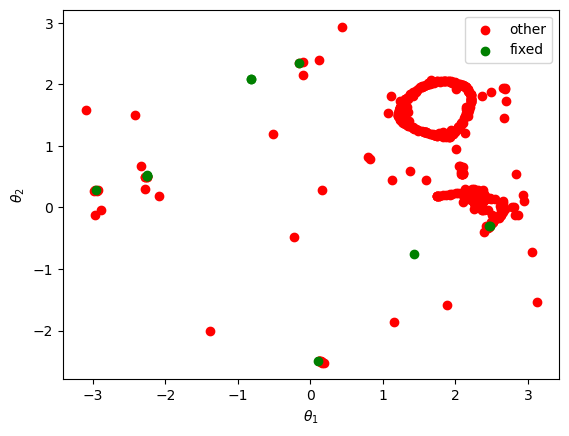

In [178]:
res_first_d = result_first[result_first['d'] <15]

fixed_first  = res_first_d[res_first_d["avg_force"] < 1e-2]
others_first = res_first_d[res_first_d["avg_force"] >= 1e-2]
print(fixed_first.shape)


plt.scatter(others_first['th1'],others_first['th2'],color='red',label = 'other')
plt.scatter(fixed_first['th1'],fixed_first['th2'],color='green',label = 'fixed')

#plt.scatter(0.07 , 2.33,color='red')
plt.legend()
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')

Text(0, 0.5, '$\\theta_2$')

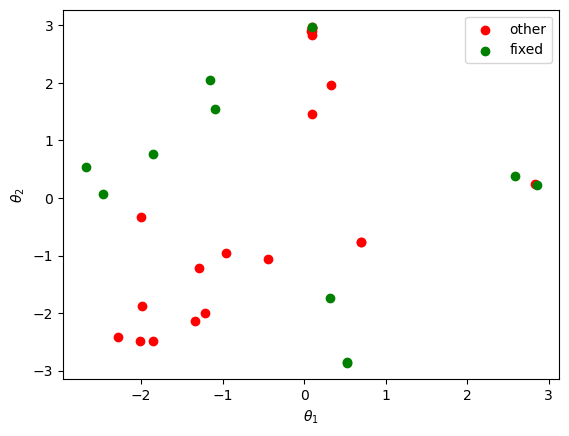

In [177]:
res_last_d = result_last[result_last['d'] <15]

fixed_last  = res_last_d[res_last_d["avg_force"] < 1e-3]
others_last = res_last_d[res_last_d["avg_force"] >= 1e-3]

plt.scatter(others_last['th1'],others_last['th2'],color='red',label = 'other')
plt.scatter(fixed_last['th1'],fixed_last['th2'],color='green',label = 'fixed')
plt.legend()
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')

In [172]:
print(result_last.head(30))

        d   th1   th2  count  avg_force
23   1.54 -2.68  0.54    699   0.000524
3    0.94  0.70 -0.76    462   0.001747
20   1.42  0.10  2.98    150   0.000861
31   4.50  2.58  0.39     27   0.000281
1    0.84 -1.85  0.76     22   0.000442
5    1.10 -1.09  1.54     19   0.000376
12   1.39  2.85  0.22     17   0.000720
2    0.94  0.70 -0.77     16   0.005159
13   1.40 -1.15  2.05     14   0.000542
32   7.56  0.63 -2.93     13   0.000214
0    0.58  0.32 -1.73      8   0.000394
33   8.52  1.79  2.24      8   0.000511
21   1.45  0.53 -2.86      8   0.000844
8    1.35 -2.47  0.07      6   0.000598
18   1.42  0.10  2.96      4   0.026943
34  13.18  3.08 -1.50      4   0.000753
24   1.80 -2.00 -0.33      3   0.004032
17   1.42  0.10  2.95      2   0.054206
19   1.42  0.10  2.97      2   0.023243
27   2.74 -2.02 -2.49      1  13.045532
4    1.00  0.09  1.46      1   4.198641
6    1.23  0.33  1.97      1   4.508304
7    1.32 -1.29 -1.22      1  13.019740
30   4.04 -1.22 -2.00      1  13.002363


In [89]:
t0 = np.random.randint(0, len(dpp))
x0 = [2.52 , 2.77-0.1  ,0.09+0.05]
traj_sim_6= Simulation_deterministic(S_first, x0, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)

In [97]:
x0 = [2.52 , 2.77-0.3  ,0.09+0.1]
traj_sim_7= Simulation_deterministic(S_first, x0, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)

In [20]:
x0_1 = [1.42, -0.17+0.1, -2.27 +0.1 ]
traj_last_1 = Simulation_deterministic(S_last, x0_1, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
x0_2 = [0.91  ,2.03+0.1 ,-0.03+0.1]
traj_last_2 = Simulation_deterministic(S_last, x0_2, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
x0_3 = [1.57 , 3.14+0.1 , 0.01+0.1]
traj_last_3 = Simulation_deterministic(S_last, x0_3, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
x0_4 = [1.45 , 0.25+0.1, -2.33+0.1] 
traj_last_4 = Simulation_deterministic(S_last, x0_4, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
x0_5= [1.5525236,-0.042377234+0.1,2.4516423 -0.1]
traj_last_5 = Simulation_deterministic(S_last, x0_5, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)

In [43]:
x0_5= [1.4240837,-0.16953254,-2.2728982]
traj_last_5 = Simulation_deterministic(S_last, x0_5, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
x0_6= [0.91 , 2.08, -0.08]
traj_last_6 = Simulation_deterministic(S_last, x0_6, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
x0_7 = [1.57, -3.2, -0.05]
traj_last_7 = Simulation_deterministic(S_last, x0_7, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)


In [45]:
x0_8 = [4, -3, 0.5]
traj_last_8 = Simulation_deterministic(S_last, x0_8, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)


(-3.0, 3.0)

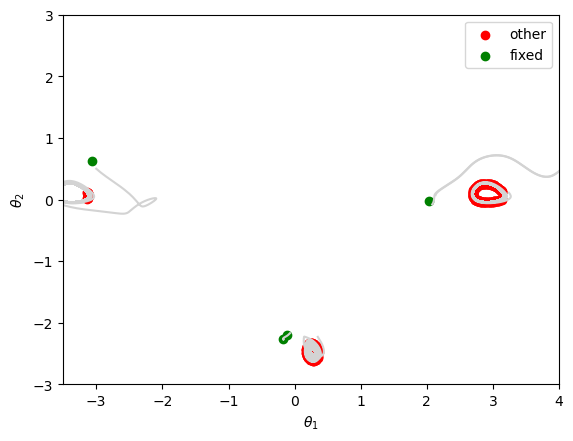

In [46]:
# last 50%
res_last_d = result_last[result_last['d'] <15]

fixed_last  = res_last_d[res_last_d["avg_force"] < 1e-2]
others_last = res_last_d[res_last_d["avg_force"] >= 1e-2]


#plt.plot(np.unwrap(traj_sim_4[15:,1]),np.unwrap(traj_sim_4[15:,2]),color='lightblue')
plt.plot(np.unwrap(traj_last_1[:,1]),np.unwrap(traj_last_1[:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_last_2[:,1]),np.unwrap(traj_last_2[:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_last_3[:,1]),np.unwrap(traj_last_3[:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_last_4[:,1]),np.unwrap(traj_last_4[:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_last_5[:,1]),np.unwrap(traj_last_5[:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_last_6[:,1]),np.unwrap(traj_last_6[:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_last_7[:,1]),np.unwrap(traj_last_7[:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_last_8[:,1]),np.unwrap(traj_last_8[:,2]),color='lightgrey')
#plt.plot(np.unwrap(traj_sim_7[15:,1]),np.unwrap(traj_sim_7[15:,2]),color='lightgrey')
#plt.plot(np.unwrap(traj_sim_2[15:,1]),np.unwrap(traj_sim[15:,2]),color='green')
#plt.plot(np.unwrap(traj_sim_3[15:,1]),np.unwrap(traj_sim[15:,2]),color='red')
#plt.scatter()

plt.scatter(others_last['th1'],others_last['th2'],color='red',label = 'other')
plt.scatter(fixed_last['th1'],fixed_last['th2'],color='green',label = 'fixed')

#plt.scatter(0.07 , 2.33,color='red')
plt.legend()
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.xlim(-3.5,4)
plt.ylim(-3,3)

Text(0, 0.5, '$\\theta_2$')

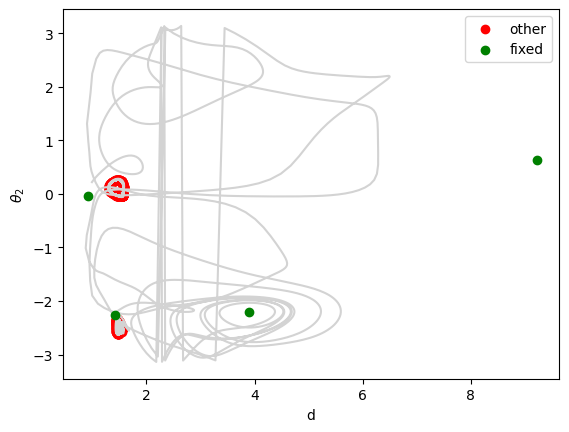

In [152]:
plt.scatter(others_last['d'],others_last['th2'],color='red',label = 'other')
plt.scatter(fixed_last['d'],fixed_last['th2'],color='green',zorder=5,label = 'fixed')
plt.plot(np.unwrap(traj_last_1[15:,0]),np.unwrap(traj_last_1[15:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_last_2[15:,0]),traj_last_2[15:,2],color='lightgrey')
plt.plot(np.unwrap(traj_last_3[15:,0]),np.unwrap(traj_last_3[15:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_last_4[15:,0]),np.unwrap(traj_last_4[15:,2]),color='lightgrey')
plt.legend()
plt.xlabel(r'd')
plt.ylabel(r'$\theta_2$')

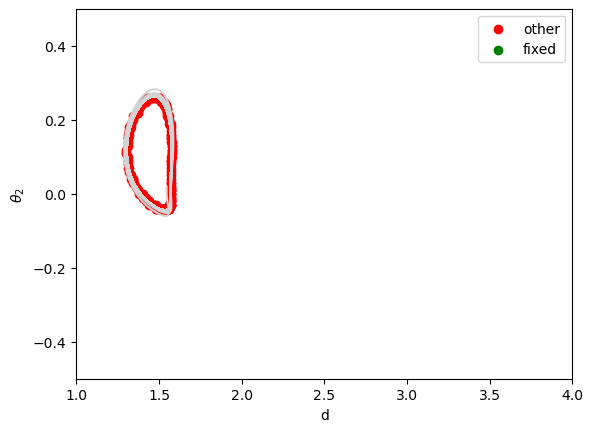

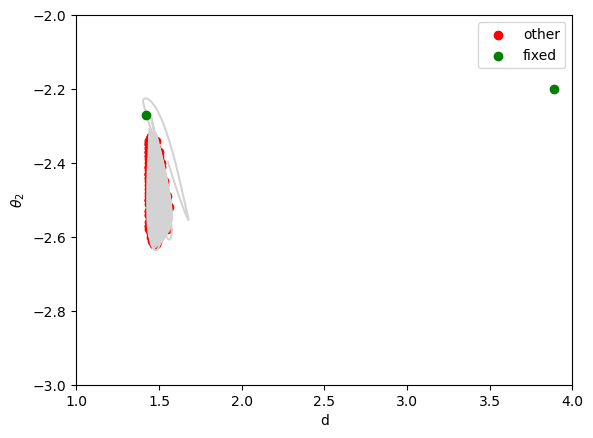

In [74]:
plt.scatter(others_last['d'],others_last['th2'],color='red',label = 'other')
plt.scatter(fixed_last['d'],fixed_last['th2'],color='green',zorder=5,label = 'fixed')
#plt.plot(np.unwrap(traj_last_1[15:,0]),np.unwrap(traj_last_1[15:,2]),color='lightgrey')
#plt.plot(np.unwrap(traj_last_2[15:,0]),np.unwrap(traj_last_2[15:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_last_3[15:,0]),np.unwrap(traj_last_3[15:,2]),color='lightgrey')
#plt.plot(np.unwrap(traj_last_4[15:,0]),np.unwrap(traj_last_4[15:,2]),color='lightgrey')
plt.xlim(1,4)
plt.ylim(-0.5,0.5)
plt.legend()
plt.xlabel(r'd')
plt.ylabel(r'$\theta_2$')
plt.show()


plt.scatter(others_last['d'],others_last['th2'],color='red',label = 'other')
plt.scatter(fixed_last['d'],fixed_last['th2'],color='green',zorder=5,label = 'fixed')
#plt.plot(np.unwrap(traj_last_1[15:,0]),np.unwrap(traj_last_1[15:,2]),color='lightgrey')
#plt.plot(np.unwrap(traj_last_2[15:,0]),np.unwrap(traj_last_2[15:,2]),color='lightgrey')
#plt.plot(np.unwrap(traj_last_3[15:,0]),np.unwrap(traj_last_3[15:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_last_4[15:,0]),np.unwrap(traj_last_4[15:,2]),color='lightgrey')
plt.xlim(1,4)
plt.ylim(-3,-2)
plt.legend()
plt.xlabel(r'd')
plt.ylabel(r'$\theta_2$')
plt.show()


In [88]:
print(result_first.head(30))

        d   th1   th2  count  avg_force
65   2.52  2.77  0.09    837   0.000639
313  4.58 -2.72  0.05     43   0.000476
137  2.99  0.10 -2.24      6   0.567165
168  3.05  0.04 -2.28      4   0.836857
144  3.00  0.09 -2.25      3   0.587810
150  3.01  0.07 -2.26      3   0.649885
457  5.82 -0.07  2.33      2   1.800824
139  2.99  0.19 -2.20      2   0.793557
138  2.99  0.18 -2.20      2   0.727192
135  2.98  0.15 -2.21      2   0.635967
133  2.98  0.14 -2.22      2   0.609509
130  2.98  0.11 -2.23      2   0.562410
440  5.67  0.16 -2.50      2   4.695428
456  5.82 -0.08 -1.93      2   3.788057
0    0.90  1.75 -1.41      2   7.003038
458  5.83 -0.07  2.32      2   1.745697
140  2.99  0.20 -2.19      2   0.819865
92   2.68 -0.83 -1.64      2   5.133880
83   2.61  0.03  2.74      2   3.137416
77   2.60 -0.90 -1.81      2   2.911250
495  6.05 -0.02 -2.42      2   2.966190
497  6.09 -0.02 -2.39      2   2.670863
501  6.10 -0.01 -2.38      2   2.545139
503  6.12 -0.03 -2.10      2   2.401771


In [95]:
print(result_first[result_first['th1']<-2])

         d   th1   th2  count  avg_force
313   4.58 -2.72  0.05     43   0.000476
551   7.79 -2.80  0.15      1   0.177888
545   7.76 -2.83  0.14      1   0.200334
547   7.77 -2.80  0.15      1   0.207740
550   7.78 -2.83  0.15      1   0.183558
543   7.72 -2.82  0.14      1   0.115445
557  20.00 -2.52 -0.09      1   4.988694


In [90]:
x0_1_first = [2.6,2.8,0.0 ]
traj_first_1 = Simulation_deterministic(S_first, x0_1_first, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
x0_2_first = [4.5,-2.65,0.0]
traj_first_2 = Simulation_deterministic(S_first, x0_2_first, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
x0_3_first = [3.0 , 0.0, -2.2 ]
traj_first_3 = Simulation_deterministic(S_first, x0_3_first, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
x0_4_first = [5.6,  0.06, -2.40 ] 
traj_first_4 = Simulation_deterministic(S_first, x0_4_first, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
x0_5_first= [2.55,  0.03,  2.64 ]
traj_first_5 = Simulation_deterministic(S_first, x0_5_first, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)

In [133]:
x0_5_first= [2.55,  0.03,  2.64 ]
traj_first_5 = Simulation_deterministic(S_first, x0_5_first, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)

In [139]:
x0_6_first= [2.45,  -0.2,  2.66]
traj_first_6 = Simulation_deterministic(S_first, x0_6_first, dt=0.01, N_steps=50000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)

Text(0, 0.5, '$\\theta_2$')

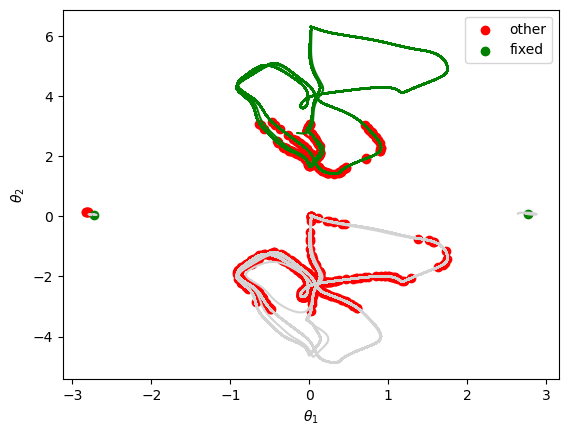

In [140]:

#theta1 = traj_sim[-2300:,1]
#theta2 = traj_sim[-2300:,2]
#theta_1 = traj_sim[-300:,1]
#theta_2 = traj_sim[-300:,2]
#print(traj_sim_5[-5:-1,0],3.14+traj_sim_5[-5:-1,1],traj_sim_5[-5:-1,2])

res_first_d = result_first[result_first['d'] <15]

fixed_first  = res_first_d[res_first_d["avg_force"] < 1e-2]
others_first = res_first_d[res_first_d["avg_force"] >= 1e-2]

#fixed_first = result_first[result_first["avg_force"] < 1e-2]
#others_first = result_first[result_first["avg_force"] >= 1e-2]

#plt.plot(np.unwrap(traj_sim_4[15:,1]),np.unwrap(traj_sim_4[15:,2]),color='lightblue')
plt.plot(np.unwrap(traj_first_1[15:,1]),np.unwrap(traj_first_1[15:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_first_2[15:,1]),np.unwrap(traj_first_2[15:,2]),color='lightgrey')
#plt.plot(np.unwrap(traj_first_3[15:,1]),np.unwrap(traj_first_3[15:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_first_4[15:,1]),np.unwrap(traj_first_4[15:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_first_5[15:,1]),np.unwrap(traj_first_5[15:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_first_6[15:,1]),np.unwrap(traj_first_6[15:,2]),color='green')

#plt.plot(np.unwrap(traj_sim_2[15:,1]),np.unwrap(traj_sim[15:,2]),color='green')
#plt.plot(np.unwrap(traj_sim_3[15:,1]),np.unwrap(traj_sim[15:,2]),color='red')
#plt.scatter()

plt.scatter(others_first['th1'],others_first['th2'],color='red',label = 'other')
plt.scatter(fixed_first['th1'],fixed_first['th2'],color='green',label = 'fixed')

#plt.scatter(0.07 , 2.33,color='red')
plt.legend()
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
#plt.savefig('Exploratory_Figures/Deterministic_nothingfixed/Trajectory_evolvefree_angles.png')

Text(0, 0.5, '$\\theta_2$')

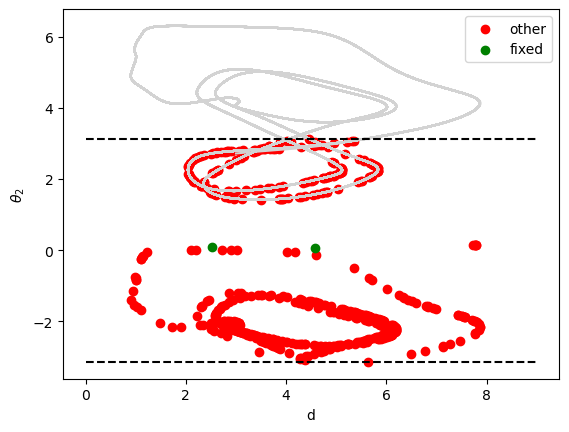

In [109]:

#plt.plot(np.unwrap(traj_sim_2[15:,1]),np.unwrap(traj_sim[15:,2]),color='green')
#plt.plot(np.unwrap(traj_sim_3[15:,1]),np.unwrap(traj_sim[15:,2]),color='red')
#plt.scatter()

plt.scatter(others_first['d'],others_first['th2'],color='red',label = 'other')
plt.scatter(fixed_first['d'],fixed_first['th2'],color='green',zorder=5,label = 'fixed')
#plt.plot(np.unwrap(traj_first_1[15:,0]),np.unwrap(traj_first_1[15:,2]),color='lightgrey')
#plt.plot(np.unwrap(traj_first_2[15:,0]),np.unwrap(traj_first_2[15:,2]),color='lightgrey')
#plt.plot(np.unwrap(traj_first_3[15:,1]),np.unwrap(traj_first_3[15:,2]),color='lightgrey')
#plt.plot(np.unwrap(traj_first_4[15:,0]),np.unwrap(traj_first_4[15:,2]),color='lightgrey')
plt.plot(np.unwrap(traj_first_5[15:,0]),np.unwrap(traj_first_5[15:,2]),color='lightgrey')
plt.hlines(np.pi,0,9, linestyle='--',colors='black')
plt.hlines(-np.pi,0,9, linestyle='--',colors='black')
plt.legend()

plt.xlabel(r'd')
plt.ylabel(r'$\theta_2$')


<bound method Axes.imshow of <Axes3D: xlabel='$\\theta_1$', ylabel='$\\theta_2$', zlabel='$d$'>>

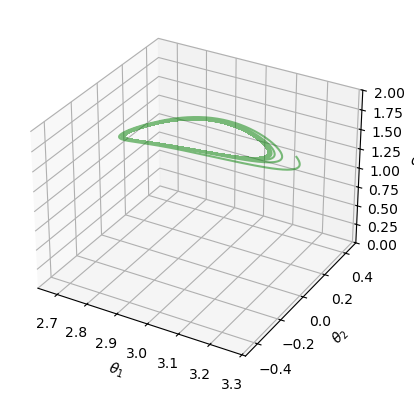

In [79]:

ax = plt.axes(projection='3d')
ax.plot3D(np.unwrap(traj_last_3[:,1]), np.unwrap(traj_last_3[:,2]), np.unwrap(traj_last_3[:,0]), alpha = 0.5,color='green')
#ax.plot3D(np.unwrap(traj_sim_2[:,1]), np.unwrap(traj_sim_2[:,2]), np.unwrap(traj_sim_2[:,0]),alpha =0.5,color= 'red')
#ax.plot3D(np.unwrap(traj_sim_3[:,1]), np.unwrap(traj_sim_3[:,2]), np.unwrap(traj_sim_3[:,0]), alpha=0.5,color='blue')
#ax.scatter3D(result_last['th1'],result_last['th2'],result_last['d'],color='red')
ax.set_xlim()
ax.set_ylim(-0.5,0.5)
ax.set_zlim(0,2)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_zlabel(r'$d$')
ax.imshow



(100.0, 150.0)

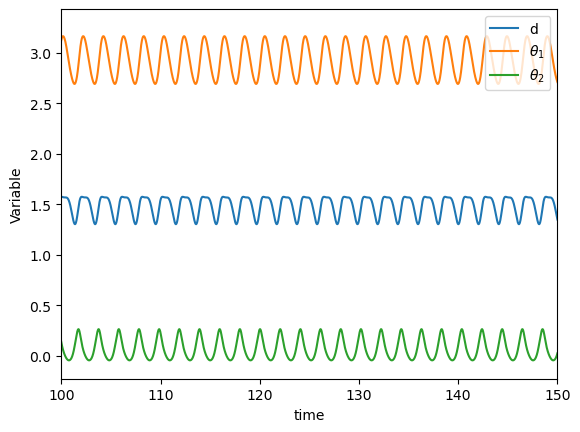

In [158]:


t0 = np.linspace(0,1000,50000)
plt.plot(t0,traj_last_3[:,0],label = 'd')
plt.plot(t0,np.unwrap(traj_last_3[:,1]),label = r'$\theta_1$')
plt.plot(t0,np.unwrap(traj_last_3[:,2]),label = r'$\theta_2$')
plt.xlabel('time')
plt.ylabel('Variable')
plt.legend()
plt.xlim(100,150)

(100.0, 150.0)

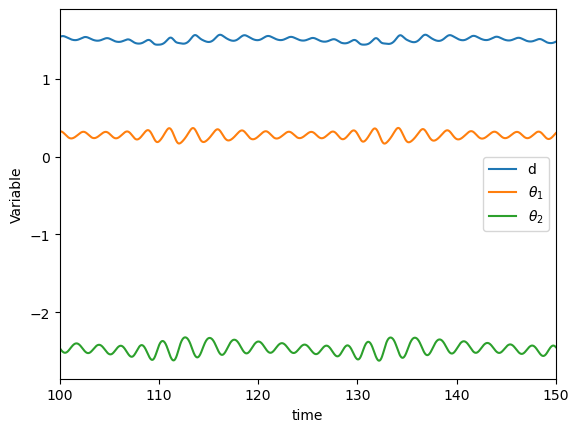

In [160]:
t0 = np.linspace(0,1000,50000)
plt.plot(t0,traj_last_4[:,0],label = 'd')
plt.plot(t0,np.unwrap(traj_last_4[:,1]),label = r'$\theta_1$')
plt.plot(t0,np.unwrap(traj_last_4[:,2]),label = r'$\theta_2$')
plt.xlabel('time')
plt.ylabel('Variable')
plt.legend()
plt.xlim(100,150)

In [161]:
print(1e-3)

0.001


<bound method Axes.imshow of <Axes3D: xlabel='$\\theta_1$', ylabel='$\\theta_2$', zlabel='$d$'>>

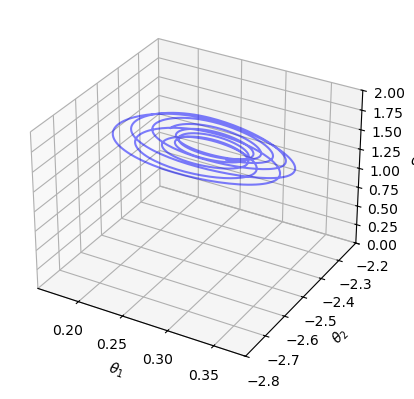

In [82]:

ax = plt.axes(projection='3d')
#ax.plot3D(np.unwrap(traj_last_3[:,1]), np.unwrap(traj_last_3[:,2]), np.unwrap(traj_last_3[:,0]), alpha = 0.5,color='green')
#ax.plot3D(np.unwrap(traj_sim_2[:,1]), np.unwrap(traj_sim_2[:,2]), np.unwrap(traj_sim_2[:,0]),alpha =0.5,color= 'red')
ax.plot3D(np.unwrap(traj_last_4[-1000:,1]), np.unwrap(traj_last_4[-1000:,2]), np.unwrap(traj_last_4[-1000:,0]), alpha=0.5,color='blue')
#ax.scatter3D(result_last['th1'],result_last['th2'],result_last['d'],color='red')
ax.set_xlim()
ax.set_ylim(-2.8,-2.2)
ax.set_zlim(0,2)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_zlabel(r'$d$')
ax.imshow

In [ ]:
ax = plt.axes(projection='3d')
#ax.plot3D(np.unwrap(traj_last_3[:,1]), np.unwrap(traj_last_3[:,2]), np.unwrap(traj_last_3[:,0]), alpha = 0.5,color='green')
#ax.plot3D(np.unwrap(traj_sim_2[:,1]), np.unwrap(traj_sim_2[:,2]), np.unwrap(traj_sim_2[:,0]),alpha =0.5,color= 'red')
ax.plot3D(np.unwrap(traj_last_4[-1000:,1]), np.unwrap(traj_last_4[-1000:,2]), np.unwrap(traj_last_4[-1000:,0]), alpha=0.5,color='blue')
#ax.scatter3D(result_last['th1'],result_last['th2'],result_last['d'],color='red')
ax.set_xlim()
ax.set_ylim(-2.8,-2.2)
ax.set_zlim(0,2)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_zlabel(r'$d$')
ax.imshow

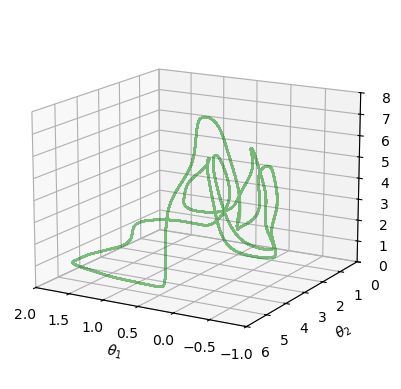

In [185]:

ax = plt.axes(projection='3d')
ax.plot3D(np.unwrap(traj_first_5[:,1]), np.unwrap(traj_first_5[:,2]), np.unwrap(traj_first_5[:,0]), alpha = 0.5,color='green')
#ax.plot3D(np.unwrap(traj_first_1[:,1]), np.unwrap(traj_first_1[:,2]), np.unwrap(traj_first_1[:,0]),alpha =0.5,color= 'red')
#ax.plot3D(np.unwrap(traj_first_2[:,1]), np.unwrap(traj_first_2[:,2]), np.unwrap(traj_first_2[:,0]), alpha=0.5,color='blue')
#ax.scatter3D(result_last['th1'],result_last['th2'],result_last['d'],color='red')
ax.set_xlim(-1,2)
ax.set_ylim(0,6)
ax.set_zlim(0,8)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_zlabel(r'$d$')
ax.view_init(elev=15, azim=120)

4999 7499
-0.9213388 1.7513855
-3.1383727 3.1415722


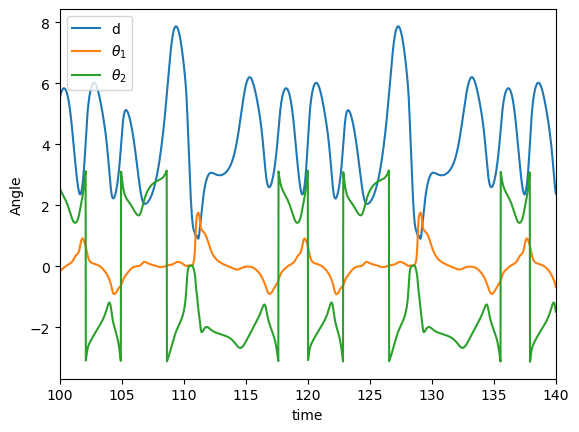

In [183]:
t0 = np.linspace(0,1000,50000)
plt.plot(t0,traj_first_5[:,0],label = 'd')
plt.plot(t0,traj_first_5[:,1],label = r'$\theta_1$')
plt.plot(t0,np.unwraptraj_first_5[:,2],label = r'$\theta_2$')
plt.xlabel('time')
plt.ylabel('Angle')
plt.legend()
plt.xlim(100,140)
dt = t0[1] - t0[0]

i_start = int(100 / dt)
i_end   = int(150 / dt)

print(i_start, i_end)

print(traj_first_5[4999:7499,1].min(),traj_first_5[4999:7499,1].max())
print(traj_first_5[4999:7499,2].min(),traj_first_5[4999:7499,2].max())

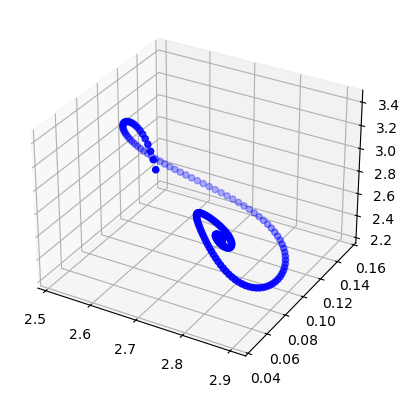

In [240]:
ax = plt.axes(projection='3d')
ax.scatter3D( traj_sim[-500:,1], traj_sim[-500:,2],traj_sim[-500:,0],color='blue')
ax.scatter3D( traj_sim[-1:,1], traj_sim[-1:,2],traj_sim[-1:,0],color='red')


In [322]:
clustered_endpoints

array([[ 2.52 ,  2.768,  0.092],
       [ 4.578, -2.725,  0.054]], dtype=float32)

### learned on first fight of expid =2
[4.117,  1.766,  1.19]
[4.107, -0.112, -2.222]

### learned on half dataset of first fight expid = 2
[ 2.52 ,  2.768,  0.092],
[ 4.578, -2.725,  0.054]

In [250]:
print(clustered_endpoints,accept_rate)
D_values = np.linspace(1,8,35)
print(D_values)

[[ 2.52   2.768  0.092]
 [ 4.578 -2.725  0.054]] [0.7916666666666666]
[1.         1.20588235 1.41176471 1.61764706 1.82352941 2.02941176
 2.23529412 2.44117647 2.64705882 2.85294118 3.05882353 3.26470588
 3.47058824 3.67647059 3.88235294 4.08823529 4.29411765 4.5
 4.70588235 4.91176471 5.11764706 5.32352941 5.52941176 5.73529412
 5.94117647 6.14705882 6.35294118 6.55882353 6.76470588 6.97058824
 7.17647059 7.38235294 7.58823529 7.79411765 8.        ]


In [43]:
np.mean([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.7844897959183673, 1.0, 1.0, 1.0, 1.0, 0.9991836734693877, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9991836734693877, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.6179591836734694, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
)

np.float64(0.9925102040816327)

[[ 2.93037963e+00 -2.17300010e+00 -1.56000003e-01]
 [ 2.93037963e+00 -1.20700002e+00 -8.60000029e-02]
 [ 2.93037963e+00  8.00000038e-03 -2.55800009e+00]
 [ 2.93037963e+00  2.47000003e+00  1.49000004e-01]
 [ 2.98101258e+00 -2.14299989e+00 -1.67999998e-01]
 [ 2.98101258e+00 -7.96999991e-01  4.89999987e-02]
 [ 2.98101258e+00 -7.96000004e-01  4.89999987e-02]
 [ 2.98101258e+00  6.00000005e-03 -2.55299997e+00]
 [ 2.98101258e+00  1.52900004e+00  1.88499999e+00]
 [ 2.98101258e+00  2.43799996e+00  1.57000005e-01]
 [ 3.03164554e+00 -2.10100007e+00 -1.84000000e-01]
 [ 3.03164554e+00 -5.50999999e-01  4.89999987e-02]
 [ 3.03164554e+00 -5.50000012e-01  4.89999987e-02]
 [ 3.03164554e+00  3.00000003e-03 -2.54800010e+00]
 [ 3.03164554e+00  1.55799997e+00  1.84300005e+00]
 [ 3.03164554e+00  2.40100002e+00  1.65000007e-01]
 [ 3.08227849e+00 -2.03299999e+00 -2.07000002e-01]
 [ 3.08227849e+00 -2.03200006e+00 -2.07000002e-01]
 [ 3.08227849e+00 -4.37999994e-01  3.99999991e-02]
 [ 3.08227849e+00  1.00000005e-

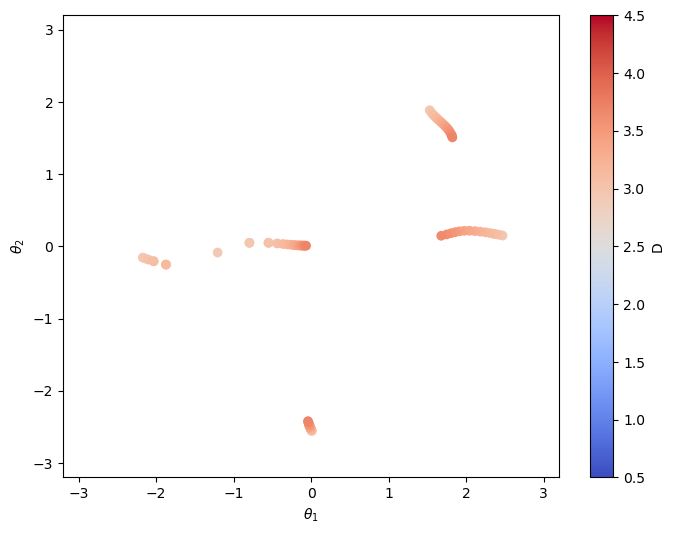

In [49]:
clustered_all = pd.read_csv("endpoints_4.5.csv").values
D_values = np.unique(clustered_all[:,0])

D_min = 2.9
D_max = 3.7

mask = (clustered_all[:,0] >= D_min) & (clustered_all[:,0] <= D_max)
data_filtered = clustered_all[mask]
print(data_filtered)


plt.figure(figsize=(8,6))
sc = plt.scatter(data_filtered[:,1],
    data_filtered[:,2],
    c=data_filtered[:,0],
                 cmap='coolwarm',vmin=D_values.min(),  
    vmax=D_values.max())

cbar = plt.colorbar(sc)
cbar.set_label("D")

plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.xlim(-3.2,3.2)
plt.ylim(-3.2,3.2)
#plt.savefig(f'Exploratory_Figures/Deterministic_simulation/Endpoint_distribution_rangeto4.5_lowD_filter.png')
plt.show()


In [150]:
def symmetry_error_components(S, D, n_samples=200):
    err_D = []
    err_th1 = []
    err_th2 = []

    for _ in range(n_samples):
        theta1 = np.random.uniform(-np.pi, np.pi)
        theta2 = np.random.uniform(-np.pi, np.pi)

        x = np.array([[D, theta1, theta2]])
        x_ref = np.array([[D, -theta1, -theta2]])

        F = np.array(S.force_ansatz(x)[0])
        F_ref = np.array(S.force_ansatz(x_ref)[0])

        # D-component should be even
        err_D.append(abs(F[0] - F_ref[0]))

        # angular components should be odd
        err_th1.append(abs(F[1] + F_ref[1]))
        err_th2.append(abs(F[2] + F_ref[2]))

    return np.mean(err_D), np.mean(err_th1), np.mean(err_th2)

print(symmetry_error_components(S, D=2.5))

(np.float32(0.9491756), np.float32(1.8329698), np.float32(2.1583655))


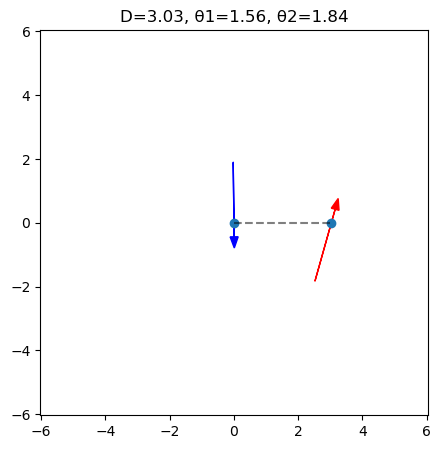

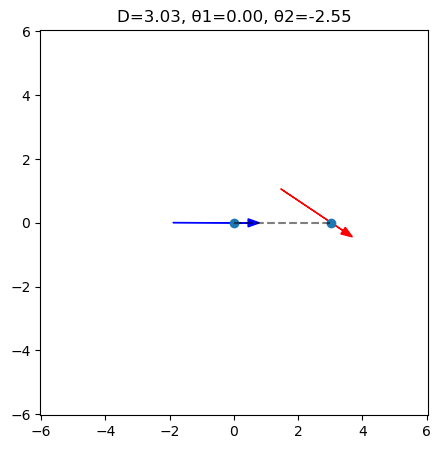

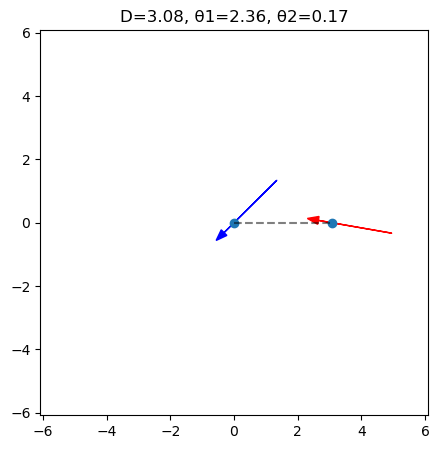

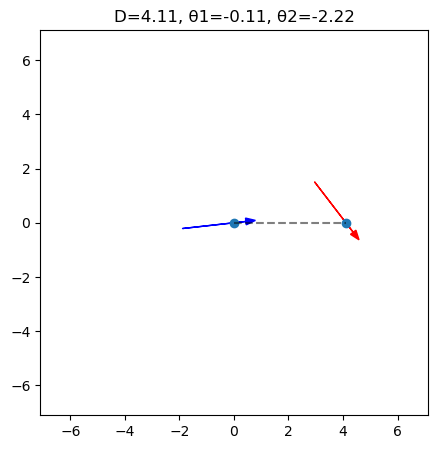

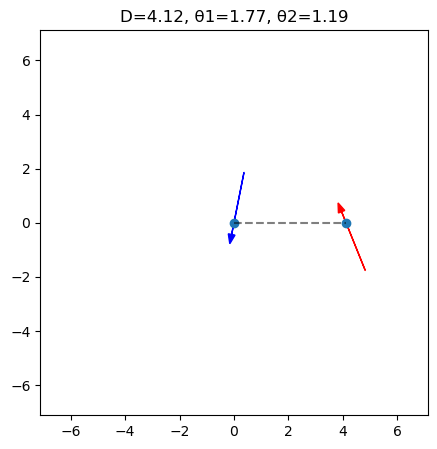

In [118]:
def plot_two_agents(D, theta1, theta2):
    L_head = 0.79
    L_tail = 1.90

    x1, y1 = 0, 0
    x2, y2 = D, 0
    theta1_abs = wrap_pi(-theta1)
    theta2_abs = wrap_pi(np.pi - theta2)

    d1 = np.array([np.cos(theta1_abs), np.sin(theta1_abs)])
    d2 = np.array([np.cos(theta2_abs), np.sin(theta2_abs)])

    tail1 = np.array([x1, y1]) - L_tail * d1
    tail2 = np.array([x2, y2]) - L_tail * d2


    vec1 = (L_head + L_tail) * d1
    vec2 = (L_head + L_tail) * d2

    plt.figure(figsize=(5,5))
    plt.arrow(*tail1, *vec1,
              head_width=0.25, head_length=0.35,
              length_includes_head=True, color='blue')

    plt.arrow(*tail2, *vec2,
              head_width=0.25, head_length=0.35,
              length_includes_head=True, color='red')

    plt.scatter([x1, x2], [y1, y2], color='tab:blue')
    plt.plot([x1, x2], [y1, y2], 'k--', alpha=0.5)

    lim = D + 3
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)

    plt.title(f"D={D:.2f}, θ1={theta1:.2f}, θ2={theta2:.2f}")
    plt.show()

plot_two_agents(3.03164554e+00 , 1.55799997e+00  ,1.84300005e+00)
plot_two_agents(3.03164554e+00,  3.00000003e-03, -2.54800010e+00)
plot_two_agents(3.08227849e+00 , 2.35700011e+00 , 1.73999995e-01)
plot_two_agents(4.107, -0.112 ,-2.222)
plot_two_agents(4.117, 1.766 ,1.19)


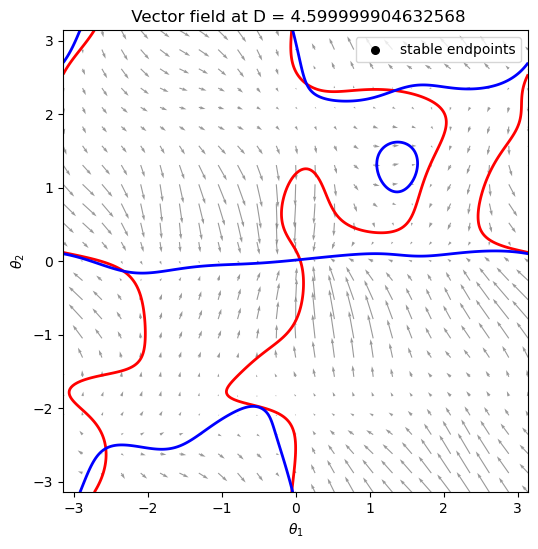

In [122]:
D_value = 4.599999904632568359e+00
theta_vals = np.linspace(-np.pi, np.pi, 300)
th1, th2 = np.meshgrid(theta_vals, theta_vals)

d_dt, th1_dt, th2_dt = F(
    np.full(th1.size, D_value),
    th1.ravel(),
    th2.ravel()
)

th1_dt = th1_dt.reshape(th1.shape)
th2_dt = th2_dt.reshape(th2.shape)

theta_vals_q = np.linspace(-np.pi, np.pi, 25)
th1_q, th2_q = np.meshgrid(theta_vals_q, theta_vals_q)

_, th1_dt_q, th2_dt_q = F(np.full(th1_q.size, D_value),th1_q.ravel(),th2_q.ravel())

plt.figure(figsize=(6,6))
plt.contour(th1, th2, th1_dt, levels=[0], colors='red', linewidths=2)
plt.contour(th1, th2, th2_dt, levels=[0], colors='blue', linewidths=2)
plt.quiver(th1_q, th2_q, th1_dt_q, th2_dt_q, color='gray', alpha=0.8)
mask = np.isclose(clustered_all[:, 0], D_value)
endpoints_D = clustered_all[mask]
plt.scatter(endpoints_D[:,1], endpoints_D[:,2], c='k', s=30, label='stable endpoints')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title(f' Vector field at D = {D_value}')
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.legend()
plt.show()

In [125]:
Theta1 = [2.2]
Theta2 = [0.8]
accept_rate = []
all_endpoints =[]
Iterations = 100
for k in range(len(Theta1)):
    accepted_trajs = []
    for i in range(Iterations):
        t0 = np.random.randint(0, len(d_pp_clean))
        #x0 = [d_sim, theta_i_clean[t0], theta_j_clean[t0]]
        x0 = [np.random.uniform(0,10), Theta1[k],Theta2[k]]
        traj_sim = Simulation_deterministic(S, x0, dt=0.01, N_steps=5000,D=None,theta1 =Theta1[k], theta2 = Theta2[k])
        if np.linalg.norm(S.force_ansatz(traj_sim[-1][None, :])[0][0]) < 1e-4:
            accepted_trajs.append(traj_sim)
    accept_rate.append(len(accepted_trajs) / Iterations)
    print('for th1=',Theta1[k],'and th2 =,',Theta2[k] ,'accept rate = ',accept_rate)

    endpoints = np.array([traj[-1] for traj in accepted_trajs])
    startpoint = np.array([traj[0] for traj in accepted_trajs])
    all_endpoints.append(endpoints)
    
    plt.figure()
    plt.scatter((startpoint[:,0]), endpoints[:,0], label ='start point')
    plt.xlabel(r'initial $D$')
    plt.ylabel(r'final $D$')
    plt.title(f'End point deterministic simulation, fixed th1={Theta1[k]:.1f} and {Theta2[k]}')
    plt.legend()
    plt.savefig(f'Exploratory_Figures/Deterministic_simulation/End_point_th1={Theta1[k]:.1f} and {Theta2[k]}.png')
    plt.close()

    plt.figure()
    plt.hist(endpoints[:,0], bins=30,range=[0,20])
    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')
    plt.title(f'Endpoint density, fixed th1={Theta1[k]:.1f} and {Theta2[k]} ')
    plt.savefig(f'Exploratory_Figures/Deterministic_simulation/Histogram_End_point_th1={Theta1[k]:.1f} and {Theta2[k]}.png')
    plt.close()
all_endpoints = np.vstack(all_endpoints)

for th1= 2.2 and th2 =, 0.8 accept rate =  [1.0]


In [ ]:
import numpy as np

save_dict = {
    "force_coefficients": np.array(S.force_coefficients),
    "diffusion": np.array(S.diffusion_average),
    "basis_names": S.force_basis_names,
    "stderr": np.array(S.force_coefficients_stderr),
}

with open("sfi_model_segmented_M3.pkl", "wb") as f:
    pickle.dump(save_dict, f)
print("Number of descriptors:", len(descriptor))
for i, d in enumerate(descriptor):
    print(i, d)